# EDA = Exploratory Data Analysis

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data

In [6]:
df = pd.read_csv('it_support_data.csv')

# Convert True/False to 1/0 for math operations.

In [9]:
df['is_breach'] = df['is_breach'].astype(int)
df['after_hours'] = df['after_hours'].astype(int)
df['repeated_issue'] = df['repeated_issue'].astype(int)

In [11]:
# Set a nice style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)  # default chart size

 CHART 1: Breach Rate by Category
 This tells the business: "Malware tickets = DANGER"

In [14]:
breach_by_cat = df.groupby('category')['is_breach'].mean() * 100
breach_by_cat = breach_by_cat.sort_values(ascending=False)                                                                                                                                                                                                                                     


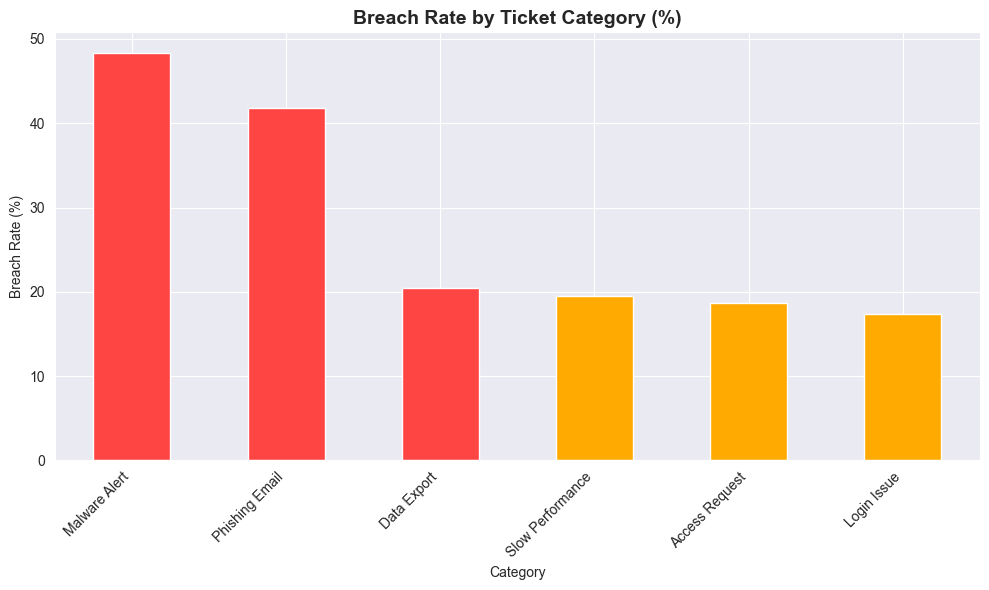

In [16]:
plt.figure()
colors = ['#ff4444' if x > 20 else '#ffaa00' if x > 10 else '#44bb44' 
          for x in breach_by_cat.values]
breach_by_cat.plot(kind='bar', color=colors)
plt.title('Breach Rate by Ticket Category (%)', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Breach Rate (%)')
plt.xticks(rotation=45, ha='right')  # tilt labels so they fit
plt.tight_layout()  # prevent labels from being cut off
plt.savefig('chart1_breach_by_category.png', dpi=150)
plt.show()

In [17]:
print("✅ Chart 1 saved")

✅ Chart 1 saved


CHART 2: Priority vs Breach Heatmap
Heatmap = color-coded grid (darker = more breaches)

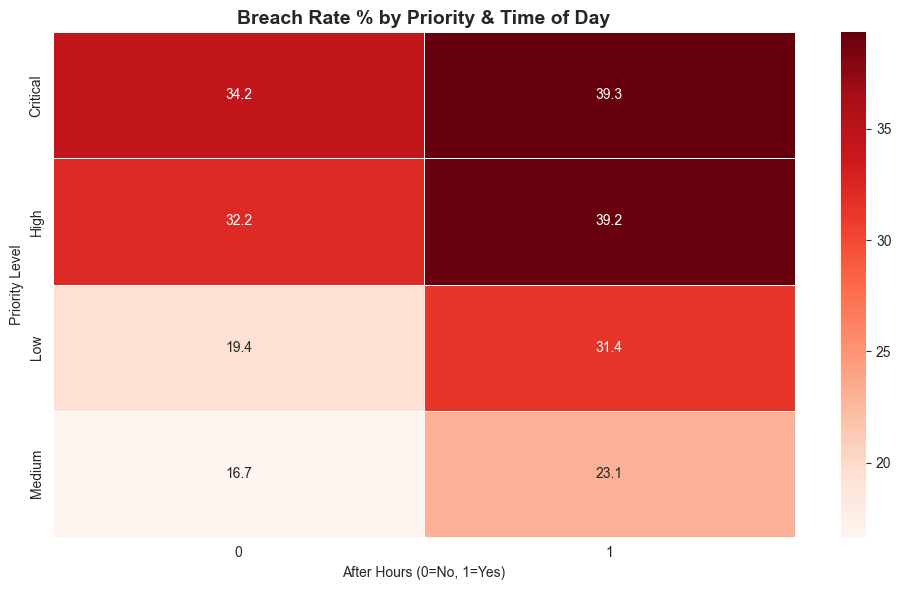

In [18]:
pivot = df.pivot_table(
    values='is_breach',      # what to calculate
    index='priority',         # rows
    columns='after_hours',    # columns (0=daytime, 1=after hours)
    aggfunc='mean'            # calculate average (breach rate)
) * 100

plt.figure()
sns.heatmap(pivot, 
            annot=True,        # show numbers inside cells
            fmt='.1f',         # 1 decimal place
            cmap='Reds',       # color: light red → dark red
            linewidths=0.5)
plt.title('Breach Rate % by Priority & Time of Day', fontsize=14, fontweight='bold')
plt.xlabel('After Hours (0=No, 1=Yes)')
plt.ylabel('Priority Level')
plt.tight_layout()
plt.savefig('chart2_heatmap.png', dpi=150)
plt.show()

In [19]:
print("✅ Chart 2 saved")

✅ Chart 2 saved


CHART 3: Monthly Trend Line
Shows: Is the problem getting better or worse?

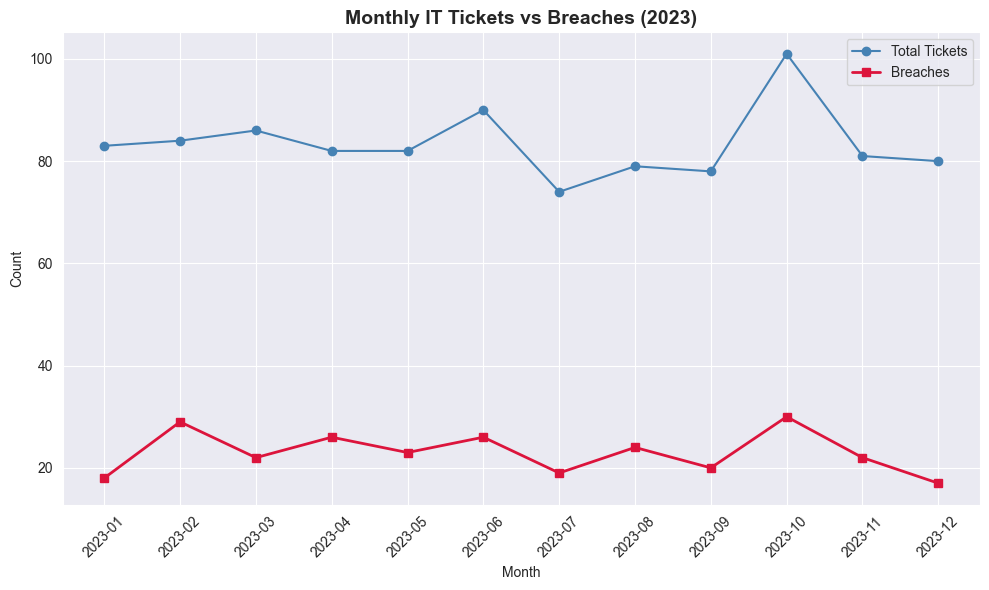

In [20]:
df['date'] = pd.to_datetime(df['date'])   # convert text to date
df['month'] = df['date'].dt.to_period('M')  # extract year-month

monthly = df.groupby('month').agg(
    total=('ticket_id', 'count'),
    breaches=('is_breach', 'sum')
).reset_index()

monthly['month_str'] = monthly['month'].astype(str)

plt.figure()
plt.plot(monthly['month_str'], monthly['total'], 
         label='Total Tickets', marker='o', color='steelblue')
plt.plot(monthly['month_str'], monthly['breaches'], 
         label='Breaches', marker='s', color='crimson', linewidth=2)
plt.title('Monthly IT Tickets vs Breaches (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('chart3_monthly_trend.png', dpi=150)
plt.show()

In [21]:
print("✅ Chart 3 saved")

✅ Chart 3 saved


in this i prepared the dataset so there are no null values so performed EDA through chart visualizations